In [1]:
import os
os.chdir('../')

In [2]:
import numpy as np
import pandas as pd

data=pd.read_csv('Datasets/data.csv',delimiter='\t')
data.head(5)

,country,surveyelapse,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,...,O7,O8,O9,O10,operatingsystem,browser,screenw,screenh,introelapse,testelapse
0,RO,174,1,1,3,3,3,2,3,1,...,5,4,5,4,Windows,Chrome,1366,768,69590,307
1,US,120,2,2,3,3,2,1,3,3,...,4,3,4,5,Macintosh,Chrome,1280,800,33657,134
2,US,99,3,3,3,3,4,3,4,4,...,5,5,4,4,Windows,Firefox,1920,1080,95550,138
3,KE,5098,1,3,4,2,4,1,5,4,...,4,2,5,4,Windows,Chrome,1600,900,4,4440
4,JP,340,1,2,3,3,2,2,2,4,...,4,1,3,2,Windows,Firefox,1920,1080,3,337


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import warnings
warnings.filterwarnings('ignore')

In [4]:
survey = data.loc[:,'E1':'O10']
survey.loc[:,['E2', 'E4', 'E6', 'E8', 'E10', 'N2', 'N4', 'A1', 'A3', 'A5', 'A7', 'C2', 'C4', 'C6', 'C8', 'O2', 'O4', 'O6']] = 5 - survey.loc[:,['E2', 'E4', 'E6', 'E8', 'E10', 'N2', 'N4', 'A1', 'A3', 'A5', 'A7', 'C2', 'C4', 'C6', 'C8', 'O2', 'O4', 'O6']]

In [5]:
survey

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,...,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
0,2,3,3,1,5,4,2,1,4,1,...,5,3,4,4,4,3,5,4,5,4
1,4,3,5,2,5,3,4,3,5,1,...,4,3,5,3,4,4,4,3,4,5
2,1,0,2,1,3,3,1,0,2,0,...,4,3,4,3,4,2,5,5,4,4
3,3,0,2,1,3,1,3,0,1,0,...,5,3,3,3,4,4,4,2,5,4
4,1,0,1,0,2,0,1,0,1,1,...,5,2,2,3,3,2,4,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4265,1,2,2,0,1,3,1,0,1,0,...,2,0,4,2,2,3,3,2,5,3
4266,1,2,5,0,4,0,2,0,1,1,...,5,1,4,0,2,2,2,3,1,2
4267,2,4,4,2,5,3,4,1,2,3,...,5,3,4,4,4,3,4,4,4,4
4268,1,0,1,0,1,0,1,0,3,0,...,4,2,3,2,1,2,3,3,4,3


In [6]:
survey.corr()

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,...,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
E1,1.000000,0.438250,0.458366,0.507528,0.485052,0.335200,0.569887,0.366254,0.481758,0.416141,...,0.052501,0.028933,0.076898,0.031519,0.204137,0.076819,0.102475,0.052247,-0.071953,0.185636
E2,0.438250,1.000000,0.428887,0.544559,0.532876,0.541996,0.460295,0.363570,0.379249,0.496935,...,0.059047,0.058799,0.046997,0.043962,0.115451,0.081882,0.065205,0.034225,-0.081763,0.146389
E3,0.458366,0.428887,1.000000,0.467945,0.568559,0.363013,0.538636,0.321272,0.406917,0.478412,...,0.033719,0.067640,0.014924,0.026370,0.168879,0.060605,0.144523,-0.036855,-0.073103,0.149204
E4,0.507528,0.544559,0.467945,1.000000,0.491781,0.460727,0.498311,0.450663,0.458169,0.526902,...,0.046850,0.073823,-0.007429,0.047843,0.143237,0.058834,0.076001,0.001852,-0.084964,0.128315
E5,0.485052,0.532876,0.568559,0.491781,1.000000,0.450109,0.582758,0.338244,0.419565,0.536438,...,0.106712,0.076769,0.078602,0.067029,0.205290,0.088834,0.145286,0.043203,-0.017271,0.216068
E6,0.335200,0.541996,0.363013,0.460727,0.450109,1.000000,0.371067,0.303088,0.334768,0.419335,...,0.174482,0.208166,0.109295,0.167307,0.236522,0.180638,0.153265,0.122644,0.032682,0.259870
E7,0.569887,0.460295,0.538636,0.498311,0.582758,0.371067,1.000000,0.333113,0.437523,0.505389,...,0.069123,0.044210,0.059893,0.028756,0.178174,0.047878,0.113621,0.038077,-0.050210,0.177681
E8,0.366254,0.363570,0.321272,0.450663,0.338244,0.303088,0.333113,1.000000,0.517064,0.393078,...,0.042683,0.070798,0.069201,0.051005,0.140637,0.094753,0.026658,0.018390,-0.067043,0.124053
E9,0.481758,0.379249,0.406917,0.458169,0.419565,0.334768,0.437523,0.517064,1.000000,0.405823,...,0.112273,0.091579,0.113669,0.060292,0.244006,0.108380,0.167326,0.129268,-0.024775,0.232448
E10,0.416141,0.496935,0.478412,0.526902,0.536438,0.419335,0.505389,0.393078,0.405823,1.000000,...,0.078279,0.115111,0.015237,0.063212,0.148421,0.079818,0.118800,0.039166,-0.102356,0.131866


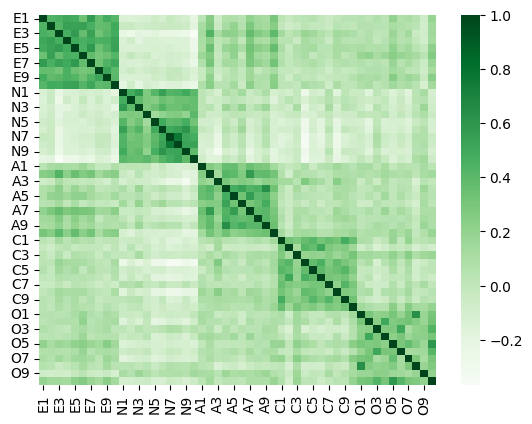

In [7]:
sns.heatmap(survey.corr(),cmap="Greens")
plt.show()

[]

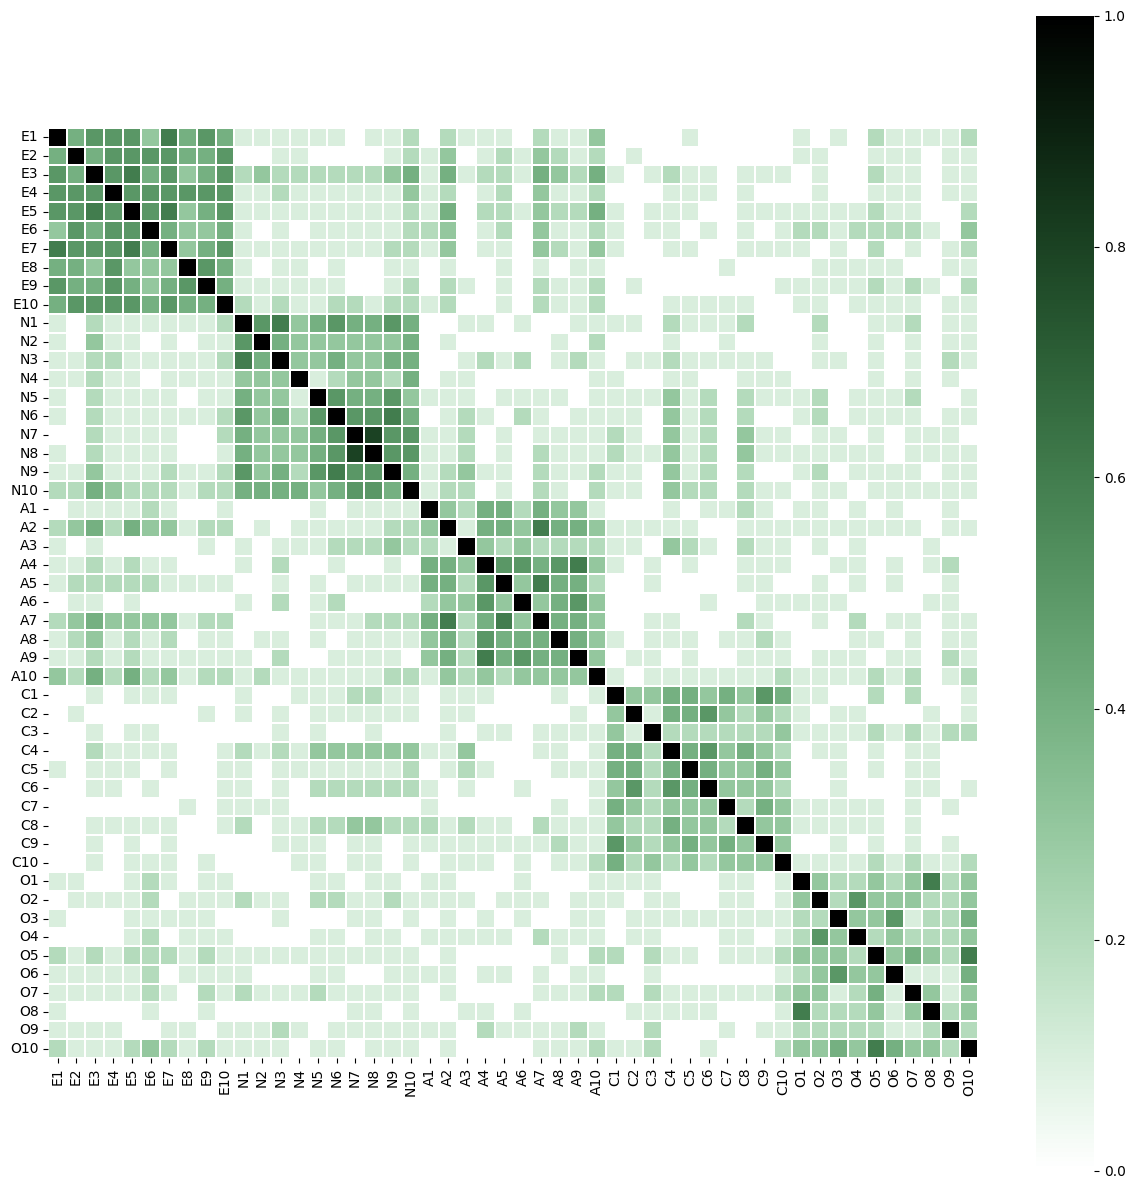

In [8]:
plt.figure(figsize=(15,15))
pal = sns.cubehelix_palette(start=2, rot=0, dark=1, light=0, reverse=True, as_cmap=True)
sns.heatmap(round(survey.corr().abs(),1), annot=False, cmap=pal, 
            linewidths=0.2, square=True)
plt.plot()

In [9]:
total_elements = len(survey.corr())**2# number of elements in correlation matrix
large_r = (survey.corr().abs()>0.3).sum().sum()  # number of correlations greater than 0.3
print('Percent correlations greater than 0.3: ', (large_r/total_elements)*100)

Percent correlations greater than 0.3:  14.719999999999999


In [10]:
chi_square, p_value = calculate_bartlett_sphericity(survey)
print(f'Chi-Square: {chi_square}')
print(f'p-value: {p_value}')

Chi-Square: 80974.62577704783
p-value: 0.0


In [11]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
survey_scaled = scale.fit_transform(survey)

In [12]:
fa = FactorAnalyzer(n_factors = 50, rotation = None)
fa.fit_transform(survey_scaled)

array([[ 0.26414582,  0.52241112, -0.14617332, ..., -0.00915185,
        -0.02318617,  0.        ],
       [ 0.21616949,  1.48187609, -0.01141112, ..., -0.00706216,
        -0.03442301,  0.        ],
       [-1.09761813, -0.58266349,  0.27186651, ..., -0.17233417,
         0.08125378,  0.        ],
       ...,
       [ 0.82341661,  0.56317825, -0.36695364, ...,  0.03378533,
        -0.00482248,  0.        ],
       [-2.39928661,  0.55836882,  0.99139968, ...,  0.13812456,
        -0.05949938,  0.        ],
       [-0.53158713, -0.02545746, -0.61254961, ...,  0.17414541,
         0.01629813,  0.        ]], shape=(4270, 50))

In [16]:
df_eigen=pd.DataFrame({'factor':np.arange(1,51),'eigen':fa.get_eigenvalues()[1]})
df_eigen.head(5)

,factor,eigen
0,1,7.465686
1,2,4.325519
2,3,3.499574
3,4,3.064223
4,5,2.518414


In [19]:
df2=df_eigen.assign(variance_explained=100*df_eigen.eigen/50)

In [21]:
df2.assign(cummulative_variance=np.cumsum(df2.variance_explained))

,factor,eigen,variance_explained,cummulative_variance
0,1,7.465686,14.931373,14.931373
1,2,4.325519,8.651037,23.582410
2,3,3.499574,6.999148,30.581558
3,4,3.064223,6.128446,36.710004
4,5,2.518414,5.036828,41.746831
5,6,1.158643,2.317285,44.064117
6,7,1.019003,2.038007,46.102123
7,8,0.706586,1.413173,47.515296
8,9,0.575431,1.150861,48.666158
9,10,0.531511,1.063022,49.729180


In [23]:
eigen_values = fa.get_eigenvalues()[0]
print('Number of factors with eigen greater than 1:', np.sum(eigen_values>1))
pd.DataFrame({'factor':np.arange(1,51),
              'eigen_value':eigen_values}).head(10)

Number of factors with eigen greater than 1: 8


,factor,eigen_value
0,1,7.811182
1,2,4.661837
2,3,3.893668
3,4,3.432943
4,5,2.892211
5,6,1.571835
6,7,1.376118
7,8,1.041158
8,9,0.973009
9,10,0.928429


Number of factors from parallel analysis: 7


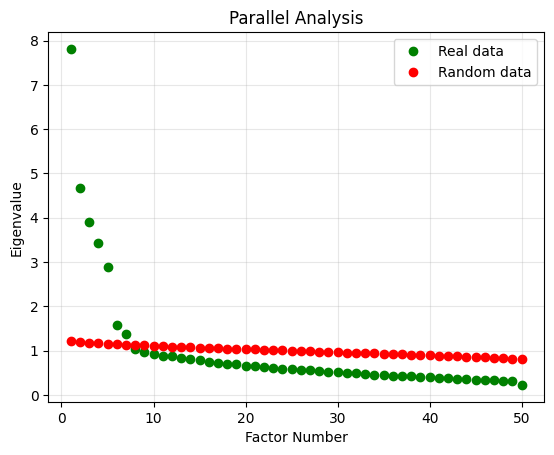

In [24]:
n_simulations = 100
random_eigenvalues = []
for _ in range(n_simulations):
    random_data = np.random.normal(0, 1, survey_scaled.shape)
    random_corr = np.corrcoef(random_data.T)
    random_eigenvals = np.linalg.eigvals(random_corr)
    random_eigenvalues.append(np.sort(random_eigenvals)[::-1])

# Calculate mean random eigenvalues
mean_random_eigenvalues = np.mean(random_eigenvalues, axis=0)

# Find where real eigenvalues exceed random
parallel_factors = sum(eigen_values > mean_random_eigenvalues)
print("Number of factors from parallel analysis:", parallel_factors)

# Plot parallel analysis
plt.plot(range(1, len(eigen_values) + 1), eigen_values, 'go', label='Real data')
plt.plot(range(1, len(mean_random_eigenvalues) + 1), mean_random_eigenvalues, 'ro', label='Random data')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.title('Parallel Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
fa1=FactorAnalyzer(n_factors=5,rotation=None)
fa1.fit(survey_scaled)
pd.DataFrame(fa1.loadings_)

,0,1,2,3,4
0,0.504968,0.256821,-0.293893,-0.106213,0.228763
1,0.492937,0.336577,-0.267447,-0.155766,0.198960
2,0.681087,0.147108,-0.109491,-0.213386,0.093087
3,0.568907,0.192969,-0.293067,-0.185750,0.227996
4,0.637662,0.277912,-0.171391,-0.114089,0.202487
5,0.510510,0.244028,-0.182766,0.067245,0.130596
6,0.575501,0.258734,-0.237154,-0.148986,0.216150
7,0.362954,0.197509,-0.310165,-0.072621,0.200199
8,0.458680,0.246733,-0.343938,0.019752,0.215977
9,0.556508,0.151059,-0.309574,-0.135340,0.180176


In [30]:
fa_unrotated = FactorAnalyzer(n_factors=5, rotation='varimax')
fa_unrotated.fit(survey_scaled)
results = pd.DataFrame(fa_unrotated.loadings_, 
             index=survey.columns, 
             columns=['Factor_1','Factor_2','Factor_3','Factor_4','Factor_5'])
results

,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5
E1,0.679357,-0.054603,0.055506,0.000703,0.057860
E2,0.687460,-0.005870,0.129021,-0.040779,0.026506
E3,0.630522,-0.259698,0.275601,0.103678,-0.000948
E4,0.712014,-0.141457,0.072114,0.031342,-0.010463
E5,0.706857,-0.099185,0.205482,0.088266,0.087988
E6,0.549123,-0.069890,0.121440,0.036490,0.229457
E7,0.702863,-0.089846,0.134873,0.041149,0.036489
E8,0.553461,-0.032896,-0.031906,-0.041712,0.046274
E9,0.637333,-0.038846,-0.023107,-0.030580,0.165594
E10,0.664997,-0.182680,0.047547,0.009562,0.034511


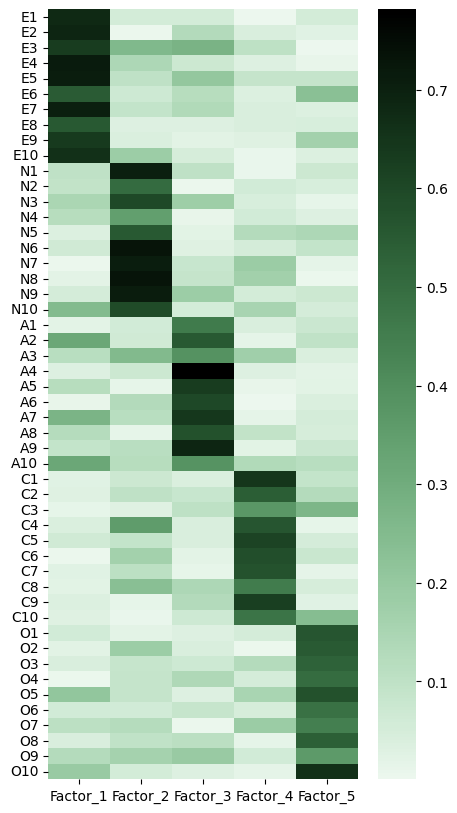

In [31]:
plt.figure(figsize = (5,10))
color_palette = sns.cubehelix_palette(start=2, rot=0, dark=0, light=.95, reverse=False, as_cmap=True)
sns.heatmap(results.abs(),cmap = color_palette)
plt.show()